# Gaussian Distribution

## Imports

In [17]:
import math
import pandas as pd
import matplotlib.pyplot as plt


## Formula

In [19]:
def formula(x,y,m,d):
    """
    x: x position
    y: y position
    m: maximum
    d: standard deviation
    """
    
    return m * np.exp(-(x **2 + y **2)/(2 * d**2))

def find_d(x,y,m,f):
    """
    x: x position
    y: y position
    m: maximum
    f: expected frequency
    """

    return math.sqrt( -0.5 * (x**2 + y**2) / math.log(f / m) )



## Parameters

In [13]:
center = (0,0)
std = 20    #mm, Gaussian profile
maximum = 500



## Real Data

In [15]:
df = pd.read_csv("data.csv")

x,y = 0, 60

# df = df[df["time"] <= time] 

#experimental
hits = df["trigger_data"].sum()
experimental_rate = hits / df.shape[0]

#theoretical
theoretical_rate = formula(x, y, maximum, std)

print(f"Experimental Rate:{experimental_rate}, Theoretical Rate: {theoretical_rate}")

Experimental Rate:0.51, Theoretical Rate: 5.554498269121153


## Sample Graph

In [ ]:
lim = 2     #bounds
n = 200     #resolution

x = np.linspace(-lim, lim, n)   #create n equally spaced nums in bounds
y = np.linspace(-lim, lim, n)   #create n equally spaced nums in bounds

X,Y = np.meshgrid(x,y)      #turn single into double arrays

Z = formula(X,Y,1,1)

fig = plt.figure(figsize = (8,6))      #Create a figure of size 8 in * 6 in
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=True, rcount=200, ccount=200)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('rate')
ax.set_title('Standard 2D Gaussian (mean=0, cov=I)')

fig.colorbar(surf, shrink=0.6, label='pdf')     #colour bar legend

ax.view_init(elev=30, azim=45)  #set cam angle

plt.show()


NameError: name 'figsize' is not defined

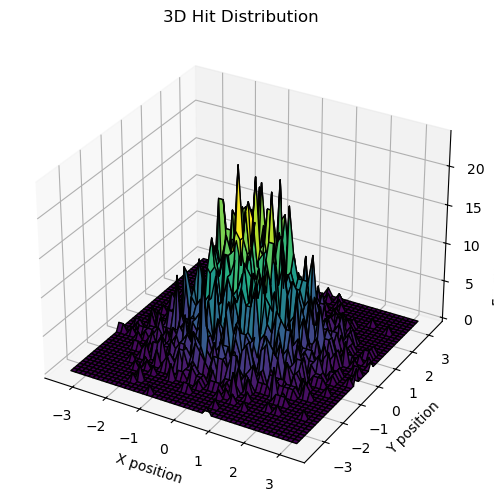

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example: generate some synthetic hit data (Gaussian beam)
N = 5000
x = np.random.normal(loc=0, scale=1.0, size=N)  # mean=0, sigma=1
y = np.random.normal(loc=0, scale=1.0, size=N)

# Make 2D histogram (this is I(x,y) ~ frequency of hits)
bins = 50
hist, xedges, yedges = np.histogram2d(x, y, bins=bins)

# Create meshgrid for plotting
X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2,
                   (yedges[:-1] + yedges[1:]) / 2)

# Plot 3D surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, hist.T, cmap="viridis", edgecolor="k")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Frequency of hits (I(x,y))")
ax.set_title("3D Hit Distribution")

plt.show()